# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

### Analyse Exploratoire

In [2]:
PATH = 'C:\\Users\\paule\\Documents\\OpenCR\\Projet 6 - ML Batiment\\opc_batimentML\\data\\2016_Building_Energy_Benchmarking.csv'

In [3]:
building_consumption = pd.read_csv(PATH)

In [4]:
# nombre de ligne et colonne avant nettoyage
building_consumption.shape

(3376, 46)

In [5]:
# On regarde comment un batiment est défini dans ce jeu de données 
pd.set_option('display.max_columns', None)
building_consumption.head(5)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [6]:
#Nettoyage
#on garde les batiments ayant default data == false
building_consumption = building_consumption[building_consumption['DefaultData'] == False]

#on supprime les batiments ayant Compliance status = missing data ou Error
bad_compliance_status = ['Error - Correct Default Data','Missing Data']
building_consumption = building_consumption[~building_consumption['ComplianceStatus'].isin(bad_compliance_status)]

#on supprime les batiments ayant low outlier and high outlier
bad_outlier = ['Low outlier','High outlier']
building_consumption = building_consumption[~building_consumption['Outlier'].isin(bad_outlier)]

In [7]:
# On garde uniquement les types de batiments non - résidentiels
building_type_to_remove = ['Multifamily LR (1-4)', 'Multifamily MR (5-9)', 'Multifamily HR (10+)']
building_consumption = building_consumption[~building_consumption['BuildingType'].isin(building_type_to_remove)]

In [8]:
# On enleve les colonnes non pertinentes pour notre analyse
columns_to_remove = ['OSEBuildingID','DataYear', 'PropertyName', 'Address','ZipCode', 'City', 'State', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Latitude', 'Longitude','Comments','DefaultData','YearsENERGYSTARCertified','PrimaryPropertyType','Outlier','ComplianceStatus']
building_consumption = building_consumption.drop(columns=columns_to_remove)

In [9]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1551 entries, 0 to 3375
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BuildingType                     1551 non-null   object 
 1   Neighborhood                     1551 non-null   object 
 2   YearBuilt                        1551 non-null   int64  
 3   NumberofBuildings                1549 non-null   float64
 4   NumberofFloors                   1551 non-null   int64  
 5   PropertyGFATotal                 1551 non-null   int64  
 6   PropertyGFAParking               1551 non-null   int64  
 7   PropertyGFABuilding(s)           1551 non-null   int64  
 8   ListOfAllPropertyUseTypes        1549 non-null   object 
 9   LargestPropertyUseType           1545 non-null   object 
 10  LargestPropertyUseTypeGFA        1545 non-null   float64
 11  SecondLargestPropertyUseType     843 non-null    object 
 12  SecondLargestPropertyUseT

colonne target = TotalGHG Emissions

In [10]:
#handle null/nan values
building_consumption = building_consumption.dropna(subset=['TotalGHGEmissions'])
building_consumption = building_consumption.dropna(subset=['Electricity(kWh)'])
building_consumption = building_consumption.dropna(subset=['LargestPropertyUseType'])

In [11]:
#valeurs aberantes (energie négative ou égale à Zero)
building_consumption = building_consumption[building_consumption['TotalGHGEmissions'] >= 0]
building_consumption = building_consumption[building_consumption['Electricity(kWh)'] > 0]
building_consumption = building_consumption[building_consumption['SiteEnergyUseWN(kBtu)'] > 0]
building_consumption = building_consumption[building_consumption['SourceEUI(kBtu/sf)'] > 0]

In [12]:
# nombre de ligne et colonne après nettoyage
building_consumption.shape

(1530, 29)

In [13]:
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1530 entries, 0 to 3375
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BuildingType                     1530 non-null   object 
 1   Neighborhood                     1530 non-null   object 
 2   YearBuilt                        1530 non-null   int64  
 3   NumberofBuildings                1530 non-null   float64
 4   NumberofFloors                   1530 non-null   int64  
 5   PropertyGFATotal                 1530 non-null   int64  
 6   PropertyGFAParking               1530 non-null   int64  
 7   PropertyGFABuilding(s)           1530 non-null   int64  
 8   ListOfAllPropertyUseTypes        1530 non-null   object 
 9   LargestPropertyUseType           1530 non-null   object 
 10  LargestPropertyUseTypeGFA        1530 non-null   float64
 11  SecondLargestPropertyUseType     836 non-null    object 
 12  SecondLargestPropertyUseT

In [14]:
#analyse des données non numériques
categorical_columns = building_consumption.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"Valeurs uniques dans la colonne {col}:")
    print(building_consumption[col].value_counts())
    print("\n")

Valeurs uniques dans la colonne BuildingType:
BuildingType
NonResidential        1415
Nonresidential COS      81
Campus                  23
SPS-District K-12       10
Nonresidential WA        1
Name: count, dtype: int64


Valeurs uniques dans la colonne Neighborhood:
Neighborhood
DOWNTOWN                  343
GREATER DUWAMISH          328
LAKE UNION                142
MAGNOLIA / QUEEN ANNE     142
EAST                      116
NORTHEAST                 113
NORTHWEST                  74
BALLARD                    57
NORTH                      51
CENTRAL                    41
DELRIDGE                   36
SOUTHEAST                  31
SOUTHWEST                  31
North                       8
Ballard                     5
Delridge                    4
Central                     4
Northwest                   3
DELRIDGE NEIGHBORHOODS      1
Name: count, dtype: int64


Valeurs uniques dans la colonne ListOfAllPropertyUseTypes:
ListOfAllPropertyUseTypes
Office                              

In [15]:
#analyse des données numériques
numerical_columns = building_consumption.select_dtypes(include=['number']).columns
building_consumption[numerical_columns].describe()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1530.000000,1530.000000,1530.000000,1.530000e+03,1530.000000,1.530000e+03,1.530000e+03,836.000000,345.000000,986.000000,1530.000000,1530.000000,1530.000000,1530.000000,1.530000e+03,1.530000e+03,1.530000e+03,1.530000e+03,1.530000e+03,1.530000e+03,1.530000e+03,1530.000000,1530.000000
mean,1961.709804,1.108497,4.257516,1.153504e+05,13801.198693,1.015492e+05,9.385936e+04,36286.591264,15055.404054,63.539554,74.940000,77.869085,183.528758,186.991503,8.284998e+06,8.507661e+06,4.931209e+05,1.676872e+06,5.721486e+06,2.050877e+04,2.050877e+06,186.871863,1.668987
std,32.779354,1.204957,6.791125,1.983996e+05,43798.619890,1.760299e+05,1.628956e+05,66781.038095,37190.929297,28.884559,75.215359,76.147718,188.499680,188.256719,2.236022e+07,2.289049e+07,5.323862e+06,4.040153e+06,1.378500e+07,9.762759e+04,9.762759e+06,731.467795,2.398502
min,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,1.400000,1.500000,4.500000,4.600000,5.713320e+04,5.811420e+04,0.000000e+00,1.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.400000,0.010000
25%,1930.000000,1.000000,1.000000,2.881100e+04,0.000000,2.784750e+04,2.500000e+04,5406.000000,2592.000000,43.250000,34.825000,37.225000,81.249998,86.199999,1.248602e+06,1.333433e+06,0.000000e+00,2.149985e+05,7.335745e+05,0.000000e+00,0.000000e+00,20.645000,0.360000
50%,1965.500000,1.000000,2.000000,4.799650e+04,0.000000,4.597000e+04,4.181350e+04,12000.000000,6000.000000,71.000000,53.750000,56.350000,138.650002,142.599998,2.701853e+06,2.828278e+06,0.000000e+00,5.064302e+05,1.727940e+06,4.962287e+03,4.962285e+05,49.940000,0.890000
75%,1989.000000,1.000000,4.000000,1.060308e+05,0.000000,9.493600e+04,9.186250e+04,31770.750000,12941.000000,88.000000,84.999998,88.200003,212.025005,215.974998,7.271161e+06,7.550202e+06,0.000000e+00,1.543338e+06,5.265868e+06,1.533766e+04,1.533766e+06,146.782500,1.980000
max,2015.000000,27.000000,99.000000,2.200000e+06,512608.000000,2.200000e+06,1.719643e+06,639931.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,4.483853e+08,4.716139e+08,1.349435e+08,8.046087e+07,2.745325e+08,2.979090e+06,2.979090e+08,16870.980000,34.090000


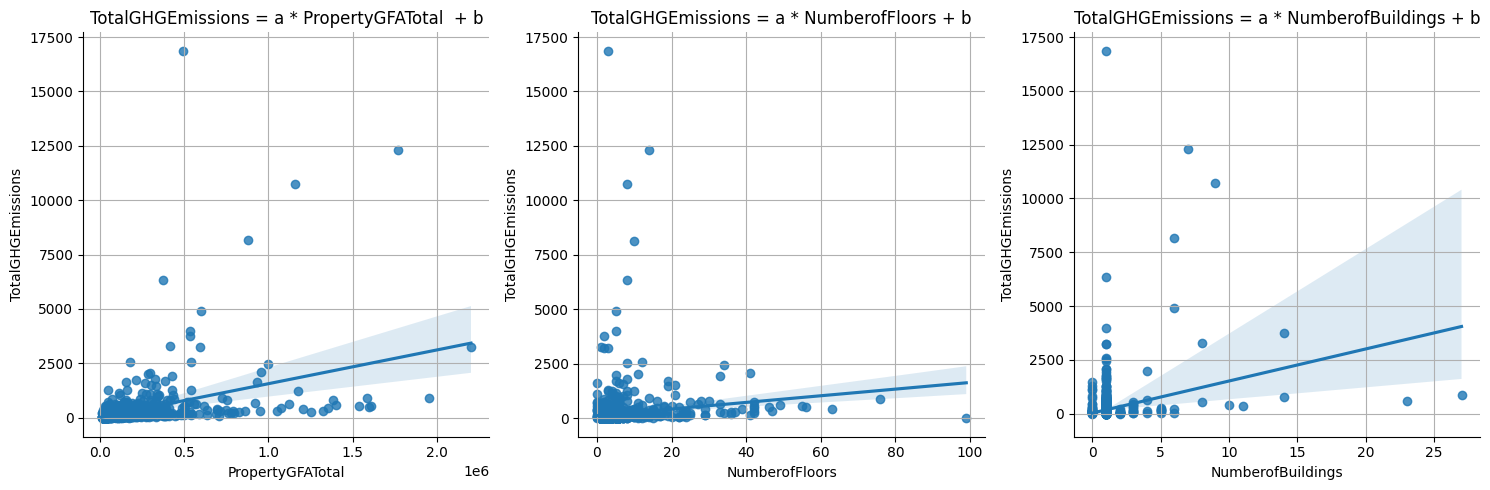

In [16]:
#relation TotalGHGEmissions et Surface, nbre batiment, nbre étage
fig, ax = plt.subplots(1,3, figsize = (15,5))

plt.subplot(1,3,1)
sns.regplot(x = building_consumption[['PropertyGFATotal']],y  =  building_consumption.TotalGHGEmissions)
plt.ylabel('TotalGHGEmissions')
plt.xlabel('PropertyGFATotal')
plt.title('TotalGHGEmissions = a * PropertyGFATotal  + b')
plt.grid()
sns.despine()

plt.subplot(1,3,2)
sns.regplot(x = building_consumption[['NumberofFloors']],y  =  building_consumption.TotalGHGEmissions)
plt.ylabel('TotalGHGEmissions')
plt.xlabel('NumberofFloors')
plt.title('TotalGHGEmissions = a * NumberofFloors + b')
plt.grid()
sns.despine()

plt.subplot(1,3,3)
res = sns.regplot(x = building_consumption[['NumberofBuildings']],y  =  building_consumption.TotalGHGEmissions)
plt.ylabel('TotalGHGEmissions')
plt.xlabel('NumberofBuildings')
plt.title('TotalGHGEmissions = a * NumberofBuildings + b')
plt.grid()
sns.despine()

plt.tight_layout()
plt.show()

In [17]:
building_consumption[numerical_columns].corr()['TotalGHGEmissions'].sort_values(ascending=False)

TotalGHGEmissions                  1.000000
SiteEnergyUseWN(kBtu)              0.921613
SiteEnergyUse(kBtu)                0.917777
NaturalGas(therms)                 0.779306
NaturalGas(kBtu)                   0.779306
ThirdLargestPropertyUseTypeGFA     0.693788
Electricity(kWh)                   0.691284
Electricity(kBtu)                  0.691284
SteamUse(kBtu)                     0.635047
SecondLargestPropertyUseTypeGFA    0.538880
LargestPropertyUseTypeGFA          0.529607
GHGEmissionsIntensity              0.502785
PropertyGFABuilding(s)             0.460014
PropertyGFATotal                   0.421593
SiteEUI(kBtu/sf)                   0.271126
SiteEUIWN(kBtu/sf)                 0.270584
NumberofBuildings                  0.245707
SourceEUI(kBtu/sf)                 0.211800
SourceEUIWN(kBtu/sf)               0.210196
NumberofFloors                     0.141528
YearBuilt                          0.075985
PropertyGFAParking                 0.060906
ENERGYSTARScore                 

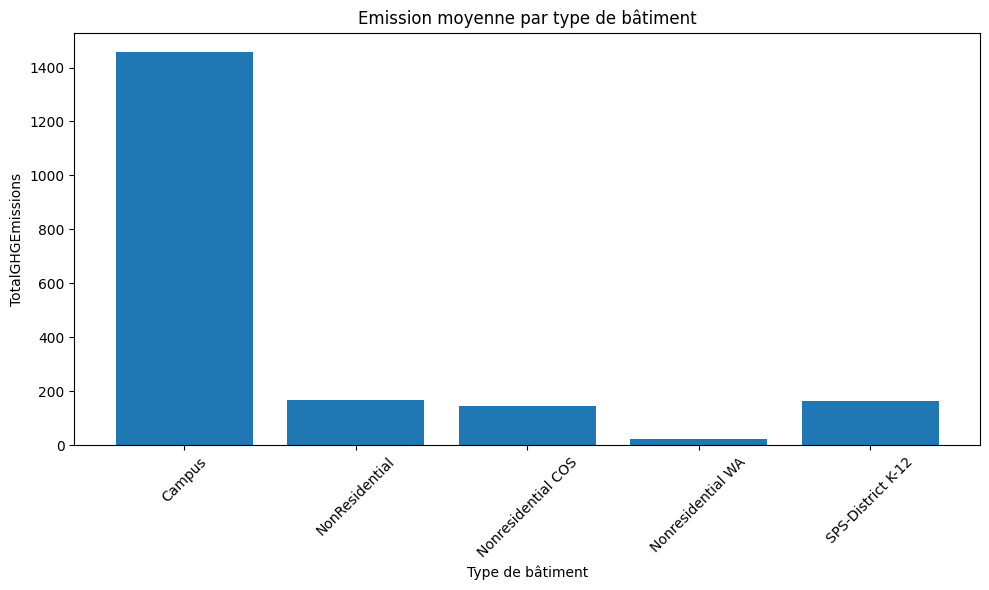

In [18]:
# Moyennes Emission par types de batiements 
moyennes = building_consumption.groupby("BuildingType")["TotalGHGEmissions"].mean()

plt.figure(figsize=(10, 6))

plt.bar(moyennes.index, moyennes.values)
plt.xlabel("Type de bâtiment")
plt.ylabel("TotalGHGEmissions")
plt.title("Emission moyenne par type de bâtiment")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
#formatiser quartier en majuscule dans Neighborhood
building_consumption['Neighborhood'] = building_consumption['Neighborhood'].str.upper()

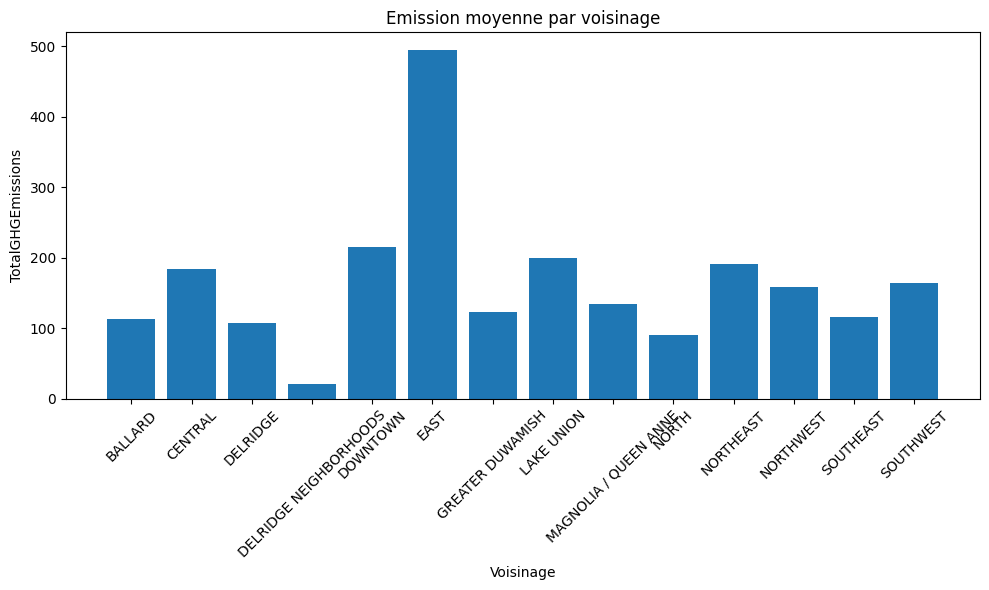

In [20]:
# Moyennes Emission par neighborhoods 
moyennes = building_consumption.groupby("Neighborhood")["TotalGHGEmissions"].mean()

plt.figure(figsize=(10, 6))

plt.bar(moyennes.index, moyennes.values)
plt.xlabel("Voisinage")
plt.ylabel("TotalGHGEmissions")
plt.title("Emission moyenne par voisinage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

# Modélisation 

### Import des modules 

In [21]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [22]:
building_consumption.head(5)

,BuildingType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
0,NonResidential,DOWNTOWN,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,249.98,2.83
1,NonResidential,DOWNTOWN,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,295.86,2.86
2,NonResidential,DOWNTOWN,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,2089.28,2.19
3,NonResidential,DOWNTOWN,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,286.43,4.67
4,NonResidential,DOWNTOWN,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,505.01,2.88


In [23]:
# Feature engineering 1 : Ratios de surface par usage
# regroupe LargestPropertyUseType en category plus large
def categorize_usage_type(usage_type):
    if usage_type in ['Office', 'Medical Office', 'Financial Office','Bank Branch', 'Data Center']:
        return 'Office'
    
    elif usage_type in ['Retail Store', 'Enclosed Mall', 'Strip Mall', 'Lifestyle Center','Automobile Dealership', 'Wholesale Club/Supercenter','Convenience Store without Gas Station']:
        return 'Retail'
    
    elif usage_type in ['Non-Refrigerated Warehouse', 'Refrigerated Warehouse','Distribution Center', 'Self-Storage Facility']:
        return 'Warehouse'
    
    elif usage_type in ['Hotel', 'Other - Lodging/Residential','Residence Hall/Dormitory', 'Senior Care Community','Residential Care Facility', 'Multifamily Housing']:
        return 'Lodging'
    
    elif usage_type in ['K-12 School', 'College/University', 'Other - Education','Adult Education', 'Pre-school/Daycare', 'Vocational School']:
        return 'Education'
    
    elif usage_type in ['Restaurant', 'Food Service', 'Fast Food Restaurant','Other - Restaurant/Bar', 'Bar/Nightclub']:
        return 'Restaurant'
    
    elif usage_type in ['Supermarket/Grocery Store', 'Food Sales']:
        return 'Grocery'
    
    elif usage_type in ['Laboratory', 'Other - Technology/Science']:
        return 'Laboratory'
    
    elif usage_type in ['Fitness Center/Health Club/Gym', 'Other - Recreation','Other - Entertainment/Public Assembly', 'Performing Arts','Movie Theater', 'Museum', 'Social/Meeting Hall','Swimming Pool']:
        return 'Recreation'
    
    elif usage_type in ['Parking']:
        return 'Parking'
    
    else:
        return 'Other'

building_consumption['LargestPropertyUseType'] = building_consumption['LargestPropertyUseType'].apply(categorize_usage_type)
building_consumption['SecondLargestPropertyUseType'] = building_consumption['SecondLargestPropertyUseType'].apply(categorize_usage_type)
building_consumption['ThirdLargestPropertyUseType'] = building_consumption['ThirdLargestPropertyUseType'].apply(categorize_usage_type)

building_consumption['LargestPropertyUseTypeGFA'] = building_consumption['LargestPropertyUseTypeGFA'].fillna(0)
building_consumption['SecondLargestPropertyUseTypeGFA'] = building_consumption['SecondLargestPropertyUseTypeGFA'].fillna(0)
building_consumption['ThirdLargestPropertyUseTypeGFA'] = building_consumption['ThirdLargestPropertyUseTypeGFA'].fillna(0)

# on crée une colonne pour chaque largest usage type category et on rempli avec le ratio de la surface correspondante
usage_type_categories = building_consumption['LargestPropertyUseType'].unique()
for usage_type in usage_type_categories:
    building_consumption[f'PropertyUseRatio_{usage_type}'] = building_consumption.apply(
        lambda row: row['LargestPropertyUseTypeGFA'] / row['PropertyGFATotal'] if row['LargestPropertyUseType'] == usage_type 
        else (row['SecondLargestPropertyUseTypeGFA'] / row['PropertyGFATotal'] if row['SecondLargestPropertyUseType'] == usage_type 
        else (row['ThirdLargestPropertyUseTypeGFA'] / row['PropertyGFATotal'] if row['ThirdLargestPropertyUseType'] == usage_type else 0)), axis=1)

building_consumption['PropertyUseRatio_Parking'] = building_consumption['PropertyGFAParking'] / building_consumption['PropertyGFATotal']
# supprime colonnes originales
building_consumption = building_consumption.drop(columns=['LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'PropertyGFAParking','PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes'])


In [24]:
# Feature engineering 2 : quels types de sources d'énergie existent au sein de chaque bâtiment
# 0 → ni gaz ni vapeur
# 1 → vapeur uniquement
# 2 → gaz uniquement
# 3 → gaz + vapeur
building_consumption['source_of_energy'] = (
      (building_consumption['NaturalGas(therms)'] > 0).astype(int) * 2
    + (building_consumption['SteamUse(kBtu)'] > 0).astype(int)
)


In [25]:
# Feature engineering 3 : Quartier East considéré comme ayant des émissions plus élevées
# Neighbohood EAST ou non
building_consumption["Neighborhood_EAST"] = (building_consumption["Neighborhood"] == "EAST").astype(int)

building_consumption = building_consumption.drop(columns=["Neighborhood"])

In [26]:
# Feature engineering 4 : calculer l'âge du bâtiment et regrouper en catégories

year = 2017

def categorize_age(age):
    if 80 <= age:
        return '80+'
    elif 50 <= age < 80:
        return '50-80'
    elif 20 <= age < 50:
        return '20-50'
    elif 0 <= age < 20:
        return '0-20'
    else:
        return 'Unknown'

building_consumption['Building_Age'] = year - building_consumption['YearBuilt']

building_consumption['Building_Age_Category'] = (
    building_consumption['Building_Age'].apply(categorize_age)
)

# Drop only original YearBuilt, keep both engineered features
building_consumption = building_consumption.drop(columns=['YearBuilt'])



### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

In [27]:
# CODE PREPARATION DES FEATURES

In [28]:
building_consumption.columns

Index(['BuildingType', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFATotal', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity',
       'PropertyUseRatio_Lodging', 'PropertyUseRatio_Other',
       'PropertyUseRatio_Recreation', 'PropertyUseRatio_Education',
       'PropertyUseRatio_Retail', 'PropertyUseRatio_Office',
       'PropertyUseRatio_Warehouse', 'PropertyUseRatio_Parking',
       'PropertyUseRatio_Restaurant', 'PropertyUseRatio_Laboratory',
       'PropertyUseRatio_Grocery', 'source_of_energy', 'Neighborhood_EAST',
       'Building_Age', 'Building_Age_Category'],
      dtype='object')

In [29]:
data_leakage = ['ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'GHGEmissionsIntensity']
building_consumption = building_consumption.drop(columns=data_leakage)

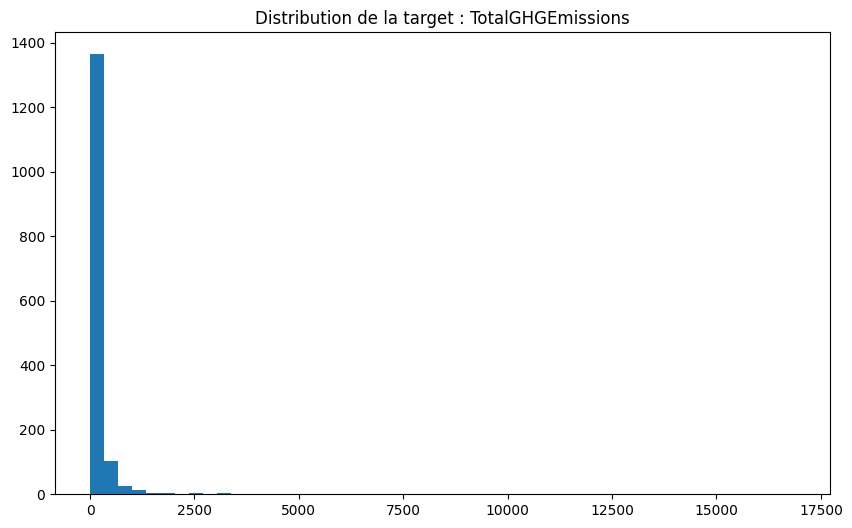

In [30]:
#distribution de la target  
plt.figure(figsize=(10,6))
plt.hist(building_consumption['TotalGHGEmissions'], bins=50)
plt.title("Distribution de la target : TotalGHGEmissions")
plt.show()

In [31]:
import numpy as np
from scipy import stats

def remove_outlier(df, column, method='IQR'):
    """
    Supprime les outliers de df[column] selon la méthode choisie.
    Retourne un NOUVEAU DataFrame filtré.
    """
    df = df.copy()  

    if method == 'IQR':
        # méthode 1 : IQR
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    elif method == 'Zscore':
        # méthode 2 : Z-score
        z = stats.zscore(df[column].astype(float)) 
        mask = np.abs(z) <= 3
        df = df[mask]

    elif method == 'quantile':
        # méthode 3 : quantiles
        lower = df[column].quantile(0.05)
        upper = df[column].quantile(0.95)

        df = df[(df[column] >= lower) & (df[column] <= upper)]

    else:
        raise ValueError("method doit être 'IQR', 'Zscore' ou 'quantile'.")

    return df


In [32]:
building_consumption = remove_outlier(
     building_consumption,
     column='TotalGHGEmissions',
     method='Zscore'
)

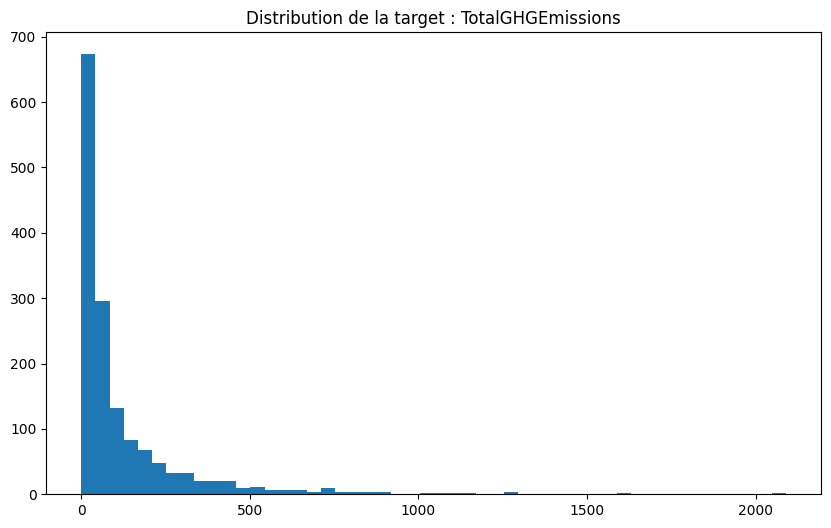

In [33]:
#distribution de la target  
plt.figure(figsize=(10,6))
plt.hist(building_consumption['TotalGHGEmissions'], bins=50)
plt.title("Distribution de la target : TotalGHGEmissions")
plt.show()

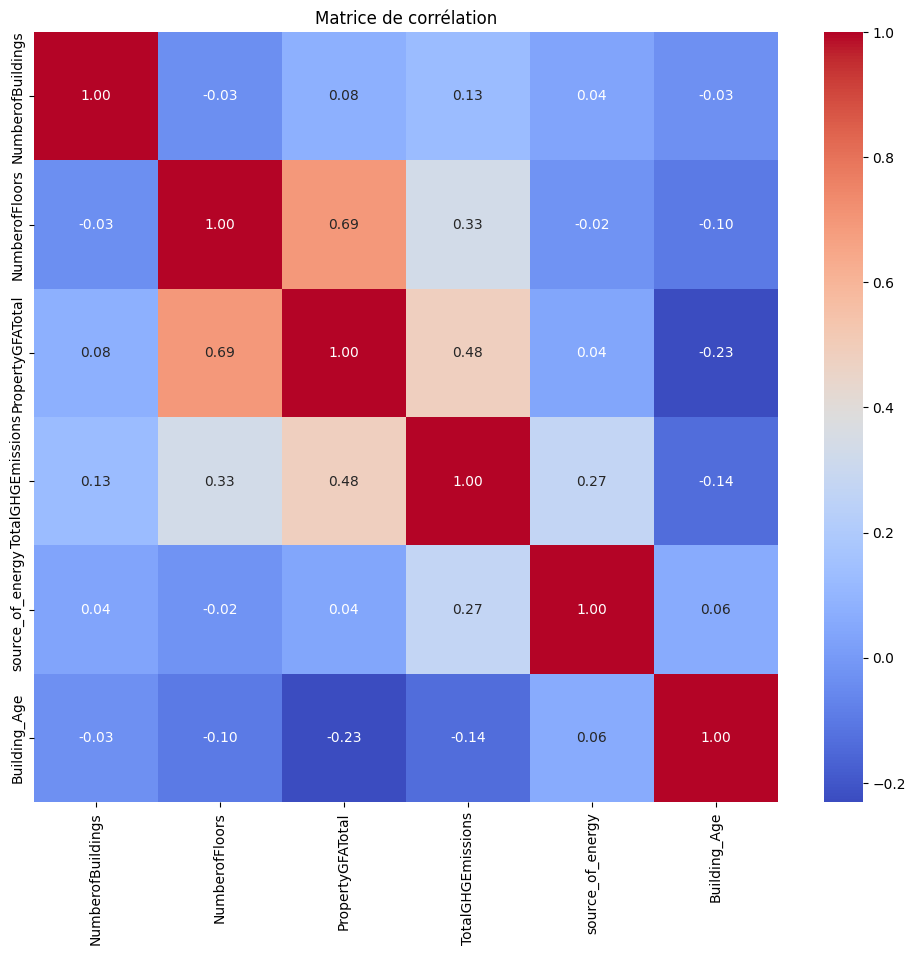

In [34]:
# matrice de corrélation colonnes numériques
numerical_columns = ['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'TotalGHGEmissions', 'source_of_energy', 'Building_Age']
plt.figure(figsize=(12,10))
sns.heatmap(building_consumption[numerical_columns].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

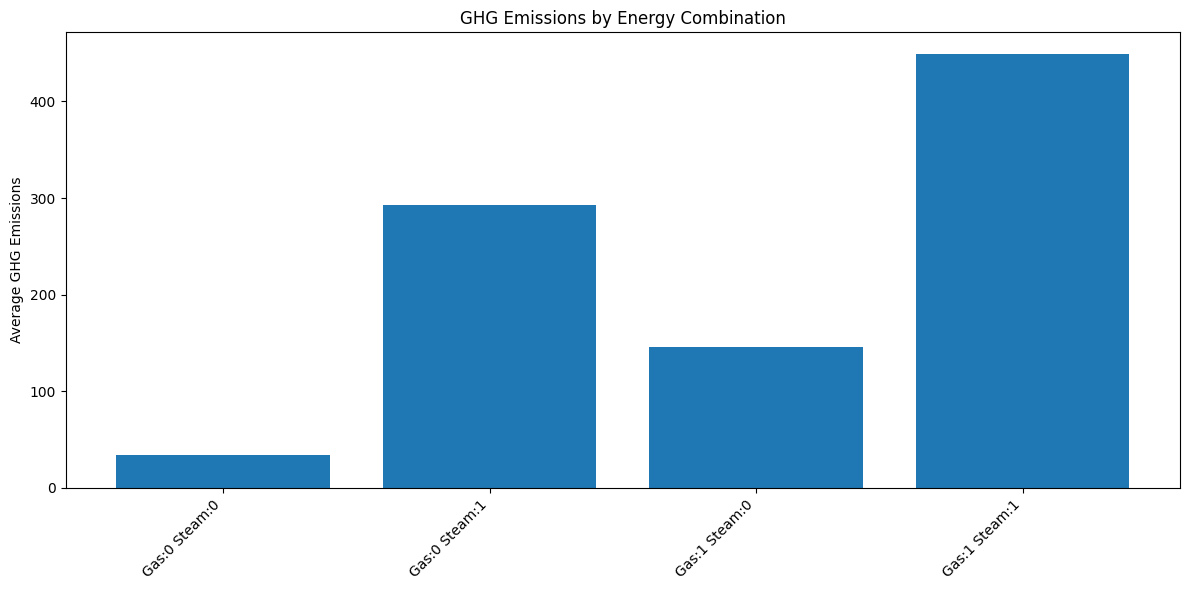

In [35]:
# GHG Emissions by Energy Combination
energy_means = (
    building_consumption
    .groupby('source_of_energy')['TotalGHGEmissions']
    .mean()
    .reset_index()
)

mapping = {
    0: "Gas:0 Steam:0",
    1: "Gas:0 Steam:1",
    2: "Gas:1 Steam:0",
    3: "Gas:1 Steam:1"
}
energy_means['label'] = energy_means['source_of_energy'].map(mapping)

plt.figure(figsize=(12, 6))

plt.bar(
    x = range(len(energy_means)),
    height = energy_means['TotalGHGEmissions']
)

plt.xticks(
    range(len(energy_means)),
    energy_means['label'],
    rotation=45,
    ha='right'
)

plt.ylabel("Average GHG Emissions")
plt.title("GHG Emissions by Energy Combination")
plt.tight_layout()
plt.show()


In [36]:
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1516 entries, 0 to 3375
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BuildingType                 1516 non-null   object 
 1   NumberofBuildings            1516 non-null   float64
 2   NumberofFloors               1516 non-null   int64  
 3   PropertyGFATotal             1516 non-null   int64  
 4   TotalGHGEmissions            1516 non-null   float64
 5   PropertyUseRatio_Lodging     1516 non-null   float64
 6   PropertyUseRatio_Other       1516 non-null   float64
 7   PropertyUseRatio_Recreation  1516 non-null   float64
 8   PropertyUseRatio_Education   1516 non-null   float64
 9   PropertyUseRatio_Retail      1516 non-null   float64
 10  PropertyUseRatio_Office      1516 non-null   float64
 11  PropertyUseRatio_Warehouse   1516 non-null   float64
 12  PropertyUseRatio_Parking     1516 non-null   float64
 13  PropertyUseRatio_Restau

In [37]:
# Préparation des features et de la target
TARGET_COL = "TotalGHGEmissions"

X = building_consumption.drop(columns=[TARGET_COL])
y = np.log1p(building_consumption[TARGET_COL]) 

In [38]:
# Séparation des colonnes numériques et catégorielles
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

In [39]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# colonne numeric : imputer median (traiter les valeurs manquantes) + standard scaler
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# colonne catégorielle : imputer most_frequent (valeur manquante) + one hot encoder 
categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine both preprocessors
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, num_cols),
        ("cat", categorical_preprocess, cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [40]:
X.head()

,BuildingType,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyUseRatio_Lodging,PropertyUseRatio_Other,PropertyUseRatio_Recreation,PropertyUseRatio_Education,PropertyUseRatio_Retail,PropertyUseRatio_Office,PropertyUseRatio_Warehouse,PropertyUseRatio_Parking,PropertyUseRatio_Restaurant,PropertyUseRatio_Laboratory,PropertyUseRatio_Grocery,source_of_energy,Neighborhood_EAST,Building_Age,Building_Age_Category
0,NonResidential,1.0,12,88434,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,3,0,90,80+
1,NonResidential,1.0,11,103566,0.809918,0.0,0.0,0.0,0.0,0.0,0.0,0.145453,0.044629,0.0,0.0,2,0,21,20-50
2,NonResidential,1.0,41,956110,0.791220,0.0,0.0,0.0,0.0,0.0,0.0,0.205748,0.000000,0.0,0.0,3,0,48,20-50
3,NonResidential,1.0,10,61320,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,3,0,91,80+
4,NonResidential,1.0,18,175580,0.703070,0.0,0.0,0.0,0.0,0.0,0.0,0.353115,0.000000,0.0,0.0,2,0,37,20-50


In [41]:
y.head()

0    5.525373
1    5.693261
2    7.645053
3    5.660979
4    6.226556
Name: TotalGHGEmissions, dtype: float64

In [42]:
# X.head(5).to_csv('C:\\Users\\paule\\Documents\\OpenCR\\Projet 6 - ML Batiment\\opc_batimentML\\data\\processed_features.csv', index=False)

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [43]:
# Comparaison de modèles (avec préprocessing dans le pipeline)
import pandas as pd
from sklearn.model_selection import KFold, cross_validate
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

def make_pipeline(model):
    return Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])

def compare_models(X, y, cv_splits=5):
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

    models = {
        "Dummy (mean)": DummyRegressor(strategy="mean"),
        "Ridge": Ridge(alpha=1.0, random_state=42),
        "SVR (RBF)": SVR(kernel="rbf", C=10.0, gamma="scale"),
        "RandomForest": RandomForestRegressor(
            n_estimators=400,
            random_state=42,
            n_jobs=-1
        ),
    }

    rows = []
    for name, model in models.items():
        pipe = make_pipeline(model)
        scores = cross_validate(
            pipe,
            X, y,
            cv=cv,
            scoring={
                "r2": "r2",
                "rmse": "neg_root_mean_squared_error",
                "mae": "neg_mean_absolute_error",
            },
            n_jobs=-1,
            return_train_score=False,
        )
        rows.append({
            "model": name,
            "R2 (cv mean)": scores["test_r2"].mean(),
            "RMSE (cv mean)": -scores["test_rmse"].mean(),
            "MAE (cv mean)": -scores["test_mae"].mean(),
        })

    return pd.DataFrame(rows).sort_values("R2 (cv mean)", ascending=False)



In [44]:
results_df = compare_models(X, y, cv_splits=5)
results_df

,model,R2 (cv mean),RMSE (cv mean),MAE (cv mean)
3,RandomForest,0.695153,0.761804,0.587346
2,SVR (RBF),0.648613,0.817595,0.617017
1,Ridge,0.554004,0.921825,0.727787
0,Dummy (mean),-0.001253,1.381786,1.109155


### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [45]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE

In [46]:
# Optimisation : GridSearchCV sur RandomForest (dans le pipeline)
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

param_grid = {
    "model__n_estimators": [400, 800],
    "model__max_depth": [None, 12, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", 0.6],
}

grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)

grid.fit(X, y)

print("Best parameters :", grid.best_params_)
print("Best CV R² score:", grid.best_score_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters : {'model__max_depth': 12, 'model__max_features': 0.6, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 400}
Best CV R² score: 0.7107822907706582


In [47]:
# No separate test set - using CV scores from GridSearch for evaluation
print("Best CV R² score:", grid.best_score_)
print("Best parameters:", grid.best_params_)

Best CV R² score: 0.7107822907706582
Best parameters: {'model__max_depth': 12, 'model__max_features': 0.6, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 400}


In [48]:
from sklearn.inspection import permutation_importance

# Interprétation : permutation importance des features

perm = permutation_importance(
    best_model,
    X, y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

feature_importance_df = (
    pd.DataFrame({
        "feature": X.columns, 
        "importance": perm.importances_mean,
        "std": perm.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance_df.head(20))

                        feature  importance       std
0              PropertyGFATotal    0.713327  0.024419
1              source_of_energy    0.529815  0.021200
2    PropertyUseRatio_Warehouse    0.127395  0.009309
3       PropertyUseRatio_Office    0.056743  0.003934
4                  Building_Age    0.041670  0.001454
5                NumberofFloors    0.033725  0.001650
6      PropertyUseRatio_Grocery    0.028931  0.001848
7        PropertyUseRatio_Other    0.016566  0.001062
8      PropertyUseRatio_Parking    0.013569  0.000780
9      PropertyUseRatio_Lodging    0.012034  0.001306
10  PropertyUseRatio_Recreation    0.011814  0.000888
11  PropertyUseRatio_Restaurant    0.011490  0.001322
12        Building_Age_Category    0.009118  0.000425
13  PropertyUseRatio_Laboratory    0.009010  0.000509
14      PropertyUseRatio_Retail    0.008982  0.000647
15                 BuildingType    0.008436  0.001147
16            NumberofBuildings    0.003221  0.000534
17            Neighborhood_E

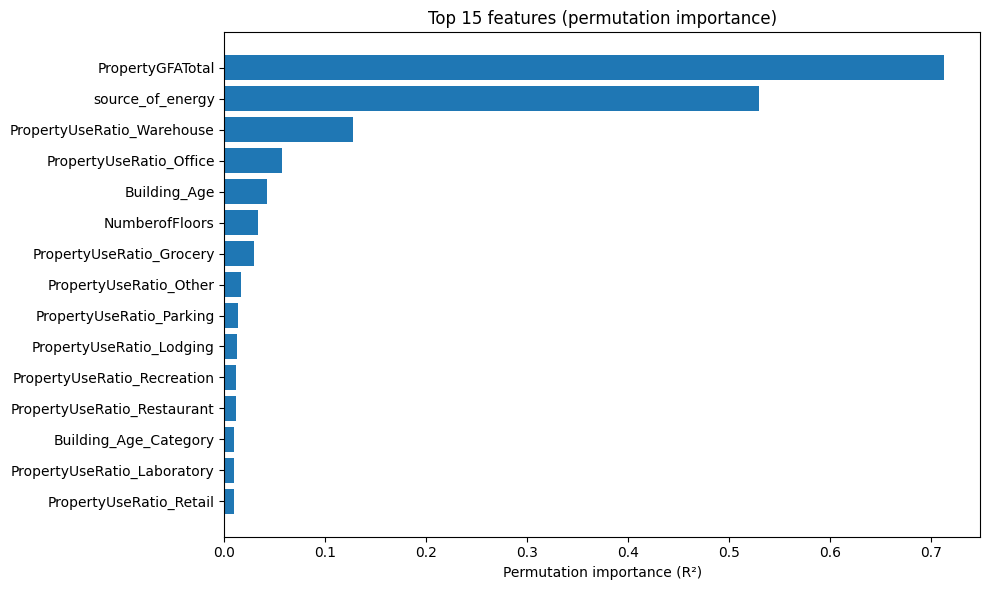

In [49]:
# Visualisation des top 15 features

top_n = 15
top_features = feature_importance_df.head(top_n).iloc[::-1] 

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Permutation importance (R²)")
plt.title(f"Top {top_n} features (permutation importance)")
plt.tight_layout()
plt.show()


In [50]:
# CODE SAUVEGARDE DU MODELE AVEC BENTOML 
import bentoml

raw_required_numeric = list(num_cols)
raw_required_categorical = list(cat_cols)
raw_required_columns = raw_required_numeric + raw_required_categorical

ratio_cols = [c for c in raw_required_columns if str(c).startswith("PropertyUseRatio_")]
use_categories = [c.replace("PropertyUseRatio_", "") for c in ratio_cols]

saved = bentoml.sklearn.save_model(
    name="energy_regressor",
    model=best_model,
    signatures={"predict": {"batchable": True}},
    custom_objects={
        "use_categories": use_categories,
        "ratio_cols": ratio_cols,
        "raw_required_numeric": raw_required_numeric,
        "raw_required_categorical": raw_required_categorical,
        "raw_required_columns": raw_required_columns,
    },
)
print(saved)


Model(tag="energy_regressor:irq5efpsig7qhbqa")
